# Recurrent example

This notebook walks through an end-to-end workflow for a **cyclic**
graph: train a small model and interpret named nodes.

It assumes you have already read the
[Getting started](../getting-started/) notebook. That tutorial covers
package basics and a feedforward `MaskedLinear` network. Here we
focus on what changes when the graph contains a feedback loop.

`parse_edgelist()` requires a DAG, so it cannot compile this graph.
Recurrence is ordinary PyTorch: one shared `MaskedLinear` over all
nodes, applied for a fixed number of steps, with input values
re-injected after each step. Weights are shared across steps. This
is not an LSTM, not a sequence model, and not a converge-until loop.


In [1]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2 as k2

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update(
    {
        "font.size": 6,
        "font.family": "Liberation Sans",
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.edgecolor": "black",
        "figure.facecolor": "none",
        "axes.facecolor": "none",
        "savefig.facecolor": "none",
    }
)
sns.set_theme(style="whitegrid")
sns.set(
    font="Liberation Sans",
    font_scale=1.0,
    rc={"font.size": 6},
)

## Define a cyclic graph

Two hidden nodes exchange feedback while input features feed each
node:

- `input_signal` is the input to `node_a`
- `input_noise` is the input to `node_b`
- `node_a` and `node_b` form a feedback loop
- `node_a` connects to the output node `output`

The first walkthrough below uses only `input_signal` as informative.
A later section repeats the same architecture under positive and
negative controls that vary which inputs carry signal.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "input_signal",
            "input_noise",
            "node_a",
            "node_b",
            "node_a",
        ],
        "target": [
            "node_a",
            "node_b",
            "node_b",
            "node_a",
            "output",
        ],
    }
)

edgelist

,source,target
0,input_signal,node_a
1,input_noise,node_b
2,node_a,node_b
3,node_b,node_a
4,node_a,output


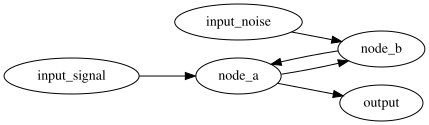

In [4]:
dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = ["input_signal", "input_noise"]
state_nodes = ["node_a", "node_b"]
output_nodes = ["output"]

for node_name in input_nodes:
    dot.node(node_name, node_name)

for node_name in state_nodes:
    dot.node(node_name, node_name)

for node_name in output_nodes:
    dot.node(node_name, node_name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

## Shared masked update, unrolled for `steps` steps

Because the graph is cyclic, we do not call `parse_edgelist()`.
Instead we:

1. collect named node sets (inputs = in-degree 0, and so on)
2. build an `n_nodes × n_nodes` adjacency mask
3. wrap that mask in `MaskedLinear`
4. apply it for a fixed number of steps, re-injecting the input
   columns after each step
5. read the output nodes and apply a linear head

Node interpretation sites are the unrolled steps (`step_1`,
`step_2`, …). Each step is its own `nn.Module` so Captum can hook
it, but they all share the same `MaskedLinear` weights.

The first walkthrough uses `steps=2`.


In [5]:
def node_sets(edgelist):
    sources = edgelist["source"].map(str).tolist()
    targets = edgelist["target"].map(str).tolist()
    nodes = sorted(set(sources) | set(targets))
    parents = {name: [] for name in nodes}
    children = {name: [] for name in nodes}
    for source, target in zip(sources, targets):
        children[source].append(target)
        parents[target].append(source)
    input_nodes = sorted(name for name in nodes if not parents[name])
    output_nodes = sorted(name for name in nodes if not children[name])
    hidden_nodes = sorted(
        name
        for name in nodes
        if name not in input_nodes and name not in output_nodes
    )
    return (
        nodes,
        input_nodes,
        hidden_nodes,
        output_nodes,
    )


def adjacency_mask(edgelist, node_names):
    index = {name: i for i, name in enumerate(node_names)}
    n_nodes = len(node_names)
    mask = torch.zeros(n_nodes, n_nodes)
    sources = edgelist["source"].map(str)
    targets = edgelist["target"].map(str)
    for source, target in zip(sources, targets):
        mask[index[target], index[source]] = 1.0
    return mask


def name_specs(
    node_names,
    input_nodes,
    hidden_nodes,
    output_nodes,
):
    align_spec = k2.GraphSpec(
        input_nodes=list(input_nodes),
        output_nodes=list(output_nodes),
        hidden_nodes=list(hidden_nodes),
        layer_nodes=[list(input_nodes)],
        layer_dims=[len(input_nodes)],
        masks=[],
        skips=[],
    )
    state_spec = k2.GraphSpec(
        input_nodes=list(input_nodes),
        output_nodes=list(output_nodes),
        hidden_nodes=list(hidden_nodes),
        layer_nodes=[list(node_names)],
        layer_dims=[len(node_names)],
        masks=[],
        skips=[],
    )
    return align_spec, state_spec

In [6]:
class RecurrentStep(nn.Module):
    def __init__(self, linear, input_index):
        super().__init__()
        object.__setattr__(self, "_linear", linear)
        self.register_buffer(
            "input_index",
            torch.as_tensor(
                input_index,
                dtype=torch.long,
            ),
        )

    def forward(self, state, x):
        state = self._linear(state)
        state = state.clone()
        state[:, self.input_index] = x
        return state


class RecurrentNet(nn.Module):
    def __init__(
        self,
        mask,
        input_index,
        output_index,
        steps,
    ):
        super().__init__()
        self.core = k2.MaskedLinear(mask)
        steps_list = []
        for _ in range(steps):
            steps_list.append(
                RecurrentStep(
                    self.core,
                    input_index,
                )
            )
        self.steps = nn.ModuleList(steps_list)
        self.register_buffer(
            "input_index",
            torch.as_tensor(
                input_index,
                dtype=torch.long,
            ),
        )
        self.register_buffer(
            "output_index",
            torch.as_tensor(
                output_index,
                dtype=torch.long,
            ),
        )
        self.head = nn.Linear(1, 1)

    def forward(self, x):
        n_nodes = self.core.in_features
        state = x.new_zeros(x.shape[0], n_nodes)
        state[:, self.input_index] = x
        for step in self.steps:
            state = step(state, x)
        output = state[:, self.output_index]
        return self.head(output)

In [7]:
node_names, input_names, hidden_names, output_names = node_sets(edgelist)
mask = adjacency_mask(edgelist, node_names)
input_index = [node_names.index(name) for name in input_names]
output_index = [node_names.index(name) for name in output_names]
align_spec, state_spec = name_specs(
    node_names,
    input_names,
    hidden_names,
    output_names,
)

model = RecurrentNet(
    mask,
    input_index,
    output_index,
    steps=2,
)
node_names, input_names, list(model.steps)

(['input_noise', 'input_signal', 'node_a', 'node_b', 'output'],
 ['input_noise', 'input_signal'],
 [RecurrentStep(), RecurrentStep()])

## Simulate data, align features, and train


In [8]:
def simulate_binary_data(
    n_per_class,
    feature_names,
    informative_features,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class
    x = rng.normal(
        0.0,
        1.0,
        size=(n_samples, n_features),
    )
    y = np.array([0] * n_per_class + [1] * n_per_class)
    informative_idx = [
        feature_names.index(name) for name in informative_features
    ]
    for class_value, shift in enumerate([-1.5, 1.5]):
        class_mask = y == class_value
        for feature_idx in informative_idx:
            x[class_mask, feature_idx] += shift
    x_df = pd.DataFrame(
        x,
        columns=feature_names,
    )
    y_series = pd.Series(y, name="label")
    return x_df, y_series

In [9]:
rng = np.random.default_rng(42)

x_train_df, y_train = simulate_binary_data(
    n_per_class=80,
    feature_names=input_names,
    informative_features=["input_signal"],
    rng=rng,
)

x_test_df, y_test = simulate_binary_data(
    n_per_class=40,
    feature_names=input_names,
    informative_features=["input_signal"],
    rng=rng,
)

x_train_df.head()

,input_noise,input_signal
0,0.304717,-2.539984
1,0.750451,-0.559435
2,-1.951035,-2.802180
3,0.127840,-1.816243
4,-0.016801,-2.353044


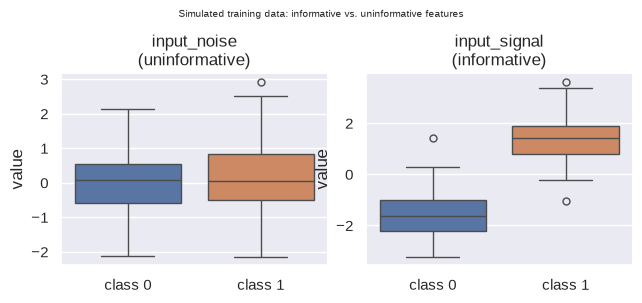

In [10]:
plot_df = x_train_df.copy()
plot_df["label"] = y_train.values
plot_df["class"] = plot_df["label"].map({0: "class 0", 1: "class 1"})

long_df = plot_df.melt(
    id_vars=["label", "class"],
    value_vars=input_names,
    var_name="feature",
    value_name="value",
)

feature_type_map = {
    "input_signal": "informative",
    "input_noise": "uninformative",
}
long_df["feature_type"] = long_df["feature"].map(feature_type_map)

g = sns.catplot(
    data=long_df,
    x="class",
    y="value",
    col="feature",
    col_wrap=2,
    hue="class",
    kind="box",
    sharey=False,
    height=3.2,
    aspect=1.0,
    legend=False,
)
g.fig.suptitle(
    "Simulated training data: informative vs. uninformative features",
    y=0.98,
)
g.fig.subplots_adjust(top=0.78, hspace=0.35)
for ax, feature in zip(g.axes.flat, input_names):
    feature_type = feature_type_map[feature]
    ax.set_title(f"{feature}\n({feature_type})")
    ax.set_xlabel("")
    ax.set_ylabel("value")
plt.show()

Loss before first update: 0.8023
Loss after final update:  0.1257


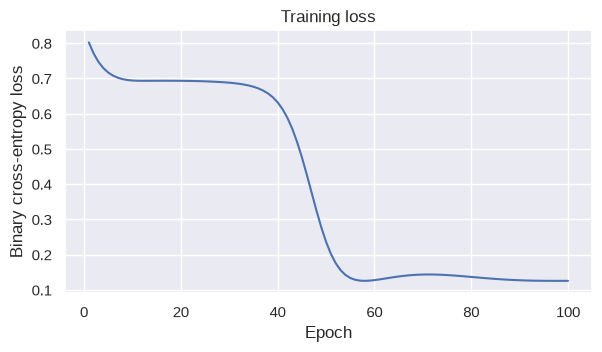

In [11]:
x_train = k2.align_inputs(x_train_df, align_spec)
x_test = k2.align_inputs(x_test_df, align_spec)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 100
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret nodes

In this first walkthrough only `input_signal` is informative.

Captum `LayerConductance` is run on each unrolled step. Then
`map_node_attributions()` labels the `(batch, n_nodes)` tensor
as xarray with the full state-vector names. Convert with
`.to_pandas()` for the tables below. `kpnn2` does not import
Captum. For the mapper itself, see
[Mapping attributions](../map-node-attributions/).

Those scores are signed. For a summary like the old peak
aggregation over steps, we keep the signed value from the step
with largest magnitude, then take `.abs()` only for ranking.
The default summary below is **hidden nodes** only (`node_a`,
`node_b`). Use the per-step tables to inspect inputs and the
output as well.


In [12]:
from captum.attr import LayerConductance

model.eval()
node_attr_by_site = {}
for step_idx, step in enumerate(model.steps, start=1):
    conductor = LayerConductance(model, step)
    attributions = conductor.attribute(
        x_test,
        target=0,
    )
    site_id = f"step_{step_idx}"
    node_attr_by_site[site_id] = k2.map_node_attributions(
        attributions=attributions,
        spec=state_spec,
        layer=0,
    ).to_pandas()

list(node_attr_by_site.keys())

['step_1', 'step_2']

In [13]:
for site_id, site_df in node_attr_by_site.items():
    print(site_id)
    display(site_df.head())

step_1


node,input_noise,input_signal,node_a,node_b,output
observation,,,,,
0,0.0,0.0,-5.821503,0.0,0.0
1,0.0,0.0,-2.579521,0.0,0.0
2,0.0,0.0,-2.648712,0.0,0.0
3,0.0,0.0,-5.395569,0.0,0.0
4,0.0,0.0,-6.949644,0.0,0.0


step_2


node,input_noise,input_signal,node_a,node_b,output
observation,,,,,
0,0.0,0.0,0.0,0.0,-5.821505
1,0.0,0.0,0.0,0.0,-2.579521
2,0.0,0.0,0.0,0.0,-2.648712
3,0.0,0.0,0.0,0.0,-5.395568
4,0.0,0.0,0.0,0.0,-6.949645


In [14]:
def peak_hidden_summary(site_tables, hidden_nodes):
    stacked = np.stack(
        [table[hidden_nodes].to_numpy() for table in site_tables],
        axis=0,
    )
    pick = np.abs(stacked).argmax(axis=0)
    n_batch, n_hidden = pick.shape
    values = np.empty((n_batch, n_hidden))
    rows = np.arange(n_batch)
    for j in range(n_hidden):
        values[:, j] = stacked[
            pick[:, j],
            rows,
            j,
        ]
    return pd.DataFrame(
        values,
        columns=hidden_nodes,
    )


node_importance = peak_hidden_summary(
    list(node_attr_by_site.values()),
    hidden_names,
)
node_importance.head()

,node_a,node_b
0,-5.821503,0.0
1,-2.579521,0.0
2,-2.648712,0.0
3,-5.395569,0.0
4,-6.949644,0.0


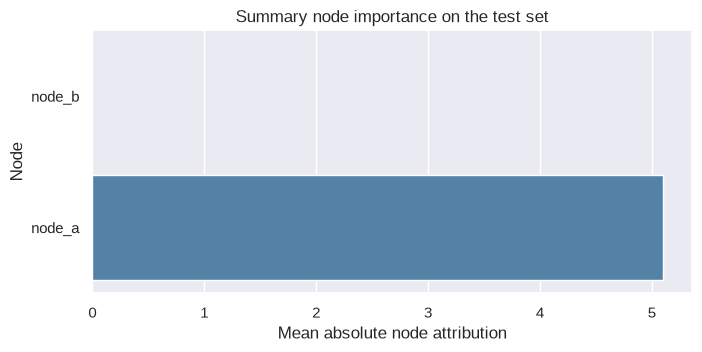

In [15]:
summary_a_only = (
    node_importance.abs()
    .mean(axis=0)
    .sort_values(ascending=True)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=summary_a_only,
    x="mean_abs_attribution",
    y="node",
    color="steelblue",
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Summary node importance on the test set")
plt.tight_layout()
plt.show()

## Positive and negative controls

The walkthrough above recovers importance on `node_a` when only
`input_signal` is informative, while `node_b` stays near zero. That
contrast is useful, but incomplete: it does not show what happens when
the other input carries signal, when both do, or when neither does.

Hidden nodes and the output stay fixed. Each case rebuilds the edgelist
and names inputs by role:

| Case | Input → `node_a` | Input → `node_b` | Expected |
| --- | --- | --- | --- |
| A only | `input_signal` | `input_noise` | `a` high, `b` ~0 |
| Both | `input_signal_a` | `input_signal_b` | both high |
| B only | `input_noise` | `input_signal` | both high |
| Neither | `input_noise_a` | `input_noise_b` | both ~0 |

A only reuses the walkthrough results above. The remaining cases use
`steps=3` so the feedback path
`input → node_b → node_a → output` can reach the output.


In [16]:
def plot_graph(edgelist, input_a, input_b):
    dot = Digraph()
    dot.attr(rankdir="LR")
    for node_name in [input_a, input_b]:
        dot.node(node_name, node_name)
    for node_name in ["node_a", "node_b"]:
        dot.node(node_name, node_name)
    dot.node("output", "output")
    for row in edgelist.itertuples(index=False):
        dot.edge(
            str(row.source),
            str(row.target),
        )
    return dot


def make_edgelist(input_a, input_b):
    return pd.DataFrame(
        {
            "source": [
                input_a,
                input_b,
                "node_a",
                "node_b",
                "node_a",
            ],
            "target": [
                "node_a",
                "node_b",
                "node_b",
                "node_a",
                "output",
            ],
        }
    )


def run_recurrent_case(
    edgelist,
    informative_features,
    steps=3,
    n_epochs=100,
):
    torch.manual_seed(42)
    rng = np.random.default_rng(42)
    (
        case_nodes,
        case_inputs,
        case_hidden,
        case_outputs,
    ) = node_sets(edgelist)
    case_mask = adjacency_mask(
        edgelist,
        case_nodes,
    )
    case_align, case_state = name_specs(
        case_nodes,
        case_inputs,
        case_hidden,
        case_outputs,
    )
    case_model = RecurrentNet(
        case_mask,
        [case_nodes.index(n) for n in case_inputs],
        [case_nodes.index(n) for n in case_outputs],
        steps,
    )
    x_train_df, y_train = simulate_binary_data(
        n_per_class=80,
        feature_names=case_inputs,
        informative_features=informative_features,
        rng=rng,
    )
    x_test_df, y_test = simulate_binary_data(
        n_per_class=40,
        feature_names=case_inputs,
        informative_features=informative_features,
        rng=rng,
    )
    x_train = k2.align_inputs(
        x_train_df,
        case_align,
    )
    x_test = k2.align_inputs(
        x_test_df,
        case_align,
    )
    y_train_tensor = torch.tensor(
        y_train.values.reshape(-1, 1),
        dtype=torch.float32,
    )
    optimizer = torch.optim.Adam(
        case_model.parameters(),
        lr=0.05,
    )
    loss_fn = nn.BCEWithLogitsLoss()
    loss_history = []
    case_model.train()
    for _ in range(n_epochs):
        optimizer.zero_grad()
        logits = case_model(x_train)
        loss = loss_fn(logits, y_train_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    case_model.eval()
    site_tables = []
    for step in case_model.steps:
        conductor = LayerConductance(
            case_model,
            step,
        )
        attributions = conductor.attribute(
            x_test,
            target=0,
        )
        site_tables.append(
            k2.map_node_attributions(
                attributions=attributions,
                spec=case_state,
                layer=0,
            ).to_pandas()
        )
    peak = peak_hidden_summary(
        site_tables,
        case_hidden,
    )
    summary = (
        peak.abs()
        .mean(axis=0)
        .sort_values(ascending=True)
        .rename("mean_abs_attribution")
        .reset_index()
        .rename(columns={"index": "node"})
    )
    return {
        "loss_history": loss_history,
        "summary": summary,
    }


def plot_case_results(
    case_name,
    result,
    attr_xlim=None,
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 3.5),
        gridspec_kw={"width_ratios": [1.1, 1.0]},
    )
    axes[0].plot(
        range(1, len(result["loss_history"]) + 1),
        result["loss_history"],
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy loss")
    axes[0].set_title(f"{case_name}: training loss")
    sns.barplot(
        data=result["summary"],
        x="mean_abs_attribution",
        y="node",
        color="steelblue",
        ax=axes[1],
    )
    axes[1].set_xlabel("Mean absolute node attribution")
    axes[1].set_ylabel("Node")
    axes[1].set_title(f"{case_name}: node importance")
    if attr_xlim is not None:
        axes[1].set_xlim(attr_xlim)
    fig.tight_layout()
    plt.show()


graph_a_only = plot_graph(
    edgelist,
    "input_signal",
    "input_noise",
)
result_a_only = {
    "loss_history": loss_history,
    "summary": summary_a_only,
}

edgelist_both = make_edgelist(
    "input_signal_a",
    "input_signal_b",
)
edgelist_b_only = make_edgelist(
    "input_noise",
    "input_signal",
)
edgelist_neither = make_edgelist(
    "input_noise_a",
    "input_noise_b",
)

graph_both = plot_graph(
    edgelist_both,
    "input_signal_a",
    "input_signal_b",
)
graph_b_only = plot_graph(
    edgelist_b_only,
    "input_noise",
    "input_signal",
)
graph_neither = plot_graph(
    edgelist_neither,
    "input_noise_a",
    "input_noise_b",
)

result_both = run_recurrent_case(
    edgelist=edgelist_both,
    informative_features=[
        "input_signal_a",
        "input_signal_b",
    ],
)
result_b_only = run_recurrent_case(
    edgelist=edgelist_b_only,
    informative_features=["input_signal"],
)
result_neither = run_recurrent_case(
    edgelist=edgelist_neither,
    informative_features=[],
)

xmax = max(
    result_a_only["summary"]["mean_abs_attribution"].max(),
    result_both["summary"]["mean_abs_attribution"].max(),
    result_b_only["summary"]["mean_abs_attribution"].max(),
    result_neither["summary"]["mean_abs_attribution"].max(),
)
attr_xlim = (0, float(xmax) * 1.05)

### Case: A only

Only the input to `node_a` (`input_signal`) is informative. The input
to `node_b` is `input_noise`. Results are taken from the walkthrough
above.


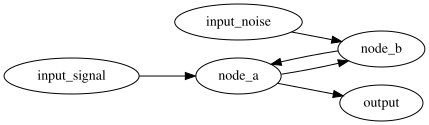

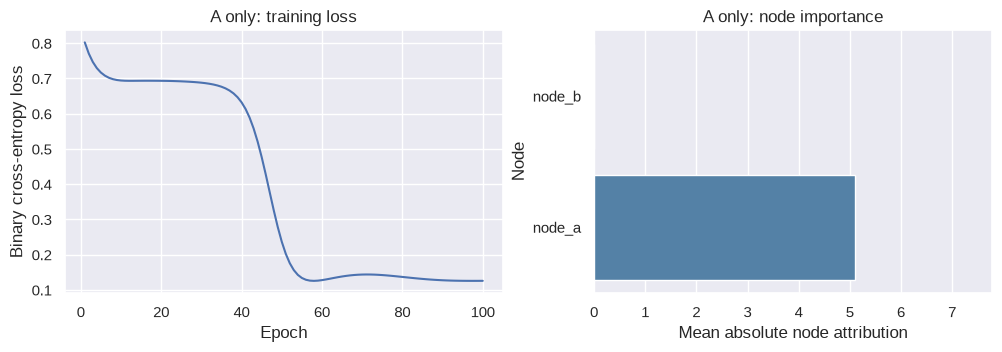

In [17]:
display(graph_a_only)
plot_case_results("A only", result_a_only, attr_xlim)

### Case: both inputs informative

Both inputs carry class signal (`input_signal_a` → `node_a`,
`input_signal_b` → `node_b`). Both hidden nodes should receive
importance.


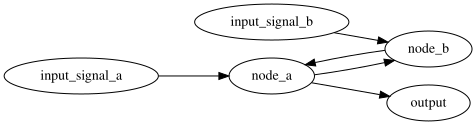

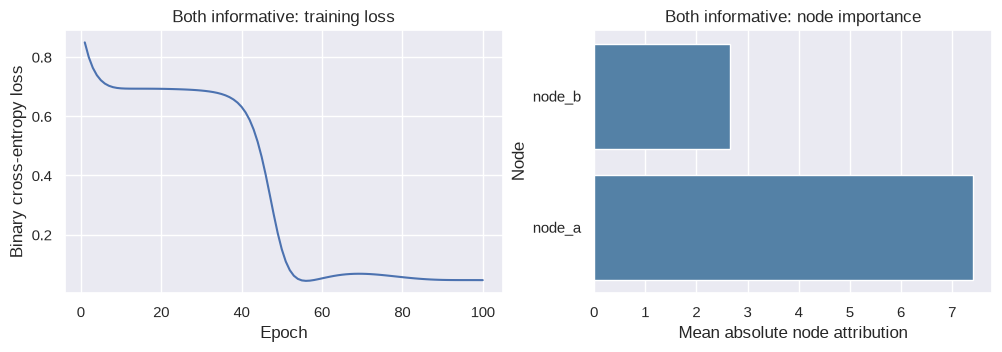

In [18]:
display(graph_both)
plot_case_results(
    "Both informative",
    result_both,
    attr_xlim,
)

### Case: B only

Only the input to `node_b` (`input_signal`) is informative. The input
to `node_a` is `input_noise`. Because only `node_a` connects to
`output`, the path
`input_signal → node_b → node_a → output` must carry the signal.
Both hidden nodes should therefore receive importance.


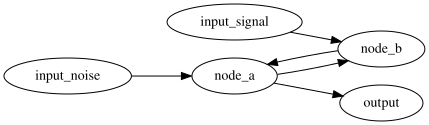

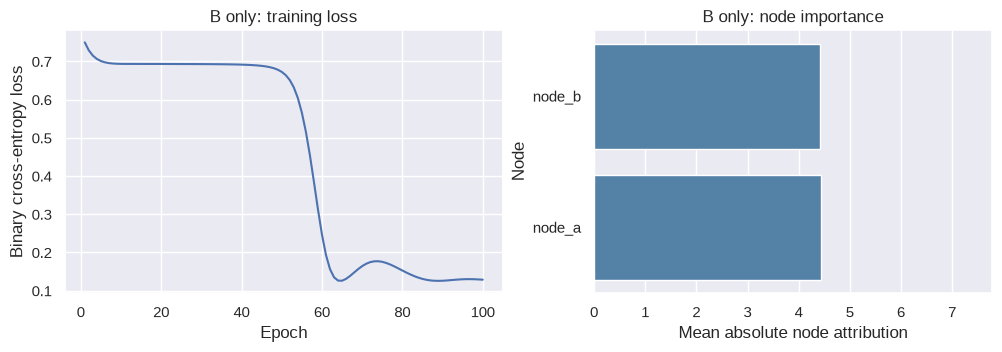

In [19]:
display(graph_b_only)
plot_case_results("B only", result_b_only, attr_xlim)

### Case: neither input informative

Both inputs are uninformative (`input_noise_a`, `input_noise_b`).
The model should not recover strong, consistent importance on either
hidden node.


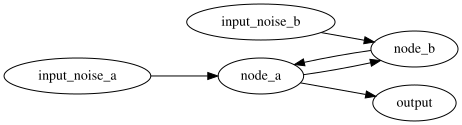

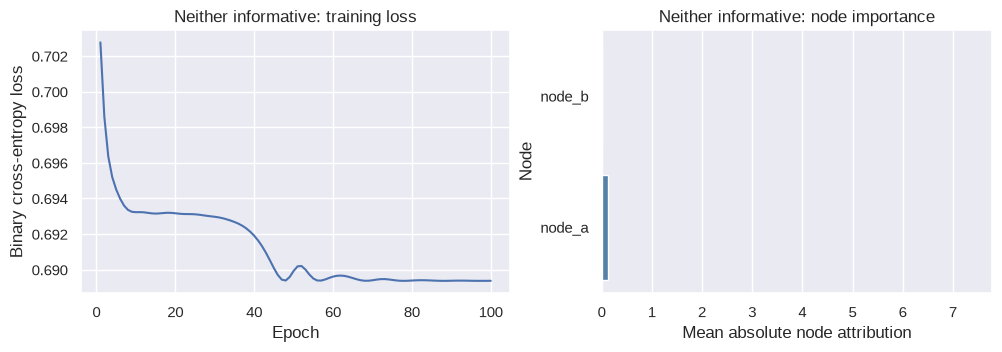

In [20]:
display(graph_neither)
plot_case_results(
    "Neither informative",
    result_neither,
    attr_xlim,
)

### Control summary

Across the four cases:

- **A only** (`input_signal` / `input_noise`): importance concentrates
  on `node_a`; `node_b` stays near zero
- **Both** (`input_signal_a` / `input_signal_b`): both hidden nodes
  receive importance
- **B only** (`input_noise` → `node_a`, `input_signal` → `node_b`):
  loss decreases and both hidden nodes receive importance via the
  feedback path to the output
- **Neither** (`input_noise_a` / `input_noise_b`): loss remains near
  chance; neither hidden node shows strong recovered importance

Low importance on `node_b` in the A-only setting therefore reflects its
uninformative input. Recovering importance through the feedback path
also requires enough unrolled steps for
`input → node_b → node_a → output` to reach the output.
